# 4.1 some simple statistics

In [2]:
import pandas as pd

aus_tourism = pd.read_csv("../data/fpp3/aus_tourism.csv")

aus_tourism

,unique_id,ds,y
0,Adelaide-South Australia-Business,1998-03-31,135.077690
1,Adelaide-South Australia-Business,1998-06-30,109.987316
2,Adelaide-South Australia-Business,1998-09-30,166.034687
3,Adelaide-South Australia-Business,1998-12-31,127.160464
4,Adelaide-South Australia-Business,1999-03-31,137.448533
...,...,...,...
24315,Yorke Peninsula-South Australia-Visiting,2016-12-31,33.672151
24316,Yorke Peninsula-South Australia-Visiting,2017-03-31,46.223014
24317,Yorke Peninsula-South Australia-Visiting,2017-06-30,50.582837
24318,Yorke Peninsula-South Australia-Visiting,2017-09-30,27.766728


In [3]:
mean_df = aus_tourism.groupby("unique_id", as_index=False)["y"].mean()
mean_df.sort_values(by="y").head(10)

,unique_id,y
158,Kangaroo Island-South Australia-Other,0.340347
182,MacDonnell-Northern Territory-Other,0.449004
294,Wilderness West-Tasmania-Other,0.478268
34,Barkly-Northern Territory-Other,0.632386
86,Clare Valley-South Australia-Other,0.897749
38,Barossa-South Australia-Other,1.021521
154,Kakadu Arnhem-Northern Territory-Other,1.042653
170,Lasseter-Northern Territory-Other,1.135796
298,Wimmera-Victoria-Other,1.146237
183,MacDonnell-Northern Territory-Visiting,1.175393


In [5]:
import tsfeatures as tsf

summary_stats = tsf.tsfeatures(aus_tourism, freq=4, features=[tsf.statistics], scale=False)

summary_stats[["unique_id", "min", "p25", "median", "p75", "max"]].head(10)


,unique_id,min,p25,median,p75,max
0,Adelaide Hills-South Australia-Business,0.000000,0.000000,1.255434,3.920368,28.601515
1,Adelaide Hills-South Australia-Holiday,0.000000,5.767673,8.515966,14.059997,35.751337
2,Adelaide Hills-South Australia-Other,0.000000,0.000000,0.907595,2.093167,8.953163
3,Adelaide Hills-South Australia-Visiting,0.777638,8.907923,12.206619,16.806339,81.102109
4,Adelaide-South Australia-Business,68.725393,133.893462,152.576618,176.935536,242.494368
5,Adelaide-South Australia-Holiday,108.033040,134.626822,153.945007,172.256676,223.557406
6,Adelaide-South Australia-Other,25.901846,43.865901,53.809463,62.523135,107.494657
7,Adelaide-South Australia-Visiting,136.611154,178.915998,205.581736,229.299111,269.535618
8,Alice Springs-Northern Territory-Business,1.008425,9.133369,13.324161,18.456365,34.077065
9,Alice Springs-Northern Territory-Holiday,2.808555,16.850803,31.523782,44.784402,76.541382


# 4.2 acf features

In [6]:
acf_feat = tsf.tsfeatures(aus_tourism, freq=4, features=[tsf.acf_features])
acf_feat.head(10).iloc[:, :5]

,unique_id,x_acf1,x_acf10,diff1_acf1,diff1_acf10
0,Adelaide Hills-South Australia-Business,0.070915,0.134473,-0.579504,0.414537
1,Adelaide Hills-South Australia-Holiday,0.131320,0.312710,-0.536153,0.500211
2,Adelaide Hills-South Australia-Other,0.261143,0.330169,-0.253227,0.317087
3,Adelaide Hills-South Australia-Visiting,0.139167,0.116787,-0.472006,0.238615
4,Adelaide-South Australia-Business,0.033271,0.130646,-0.519622,0.462537
5,Adelaide-South Australia-Holiday,0.045570,0.371898,-0.342625,0.614365
6,Adelaide-South Australia-Other,0.516806,1.153598,-0.408620,0.382891
7,Adelaide-South Australia-Visiting,0.068365,0.294237,-0.393654,0.452291
8,Alice Springs-Northern Territory-Business,0.217424,0.366634,-0.499585,0.380557
9,Alice Springs-Northern Territory-Holiday,-0.006605,2.113374,-0.152790,2.113436


# 4.3 stl features

In [7]:
stl_feat = tsf.tsfeatures(aus_tourism, freq=4, features=[tsf.stl_features])
stl_feat.head(10).iloc[:, :5]

,unique_id,nperiods,seasonal_period,trend,spike
0,Adelaide Hills-South Australia-Business,1,4,0.459551,0.000322
1,Adelaide Hills-South Australia-Holiday,1,4,0.531073,0.000105
2,Adelaide Hills-South Australia-Other,1,4,0.589967,0.000053
3,Adelaide Hills-South Australia-Visiting,1,4,0.487016,0.000580
4,Adelaide-South Australia-Business,1,4,0.461801,0.000097
5,Adelaide-South Australia-Holiday,1,4,0.577813,0.000017
6,Adelaide-South Australia-Other,1,4,0.746461,0.000024
7,Adelaide-South Australia-Visiting,1,4,0.448953,0.000048
8,Alice Springs-Northern Territory-Business,1,4,0.551599,0.000052
9,Alice Springs-Northern Territory-Holiday,1,4,0.379298,0.000007


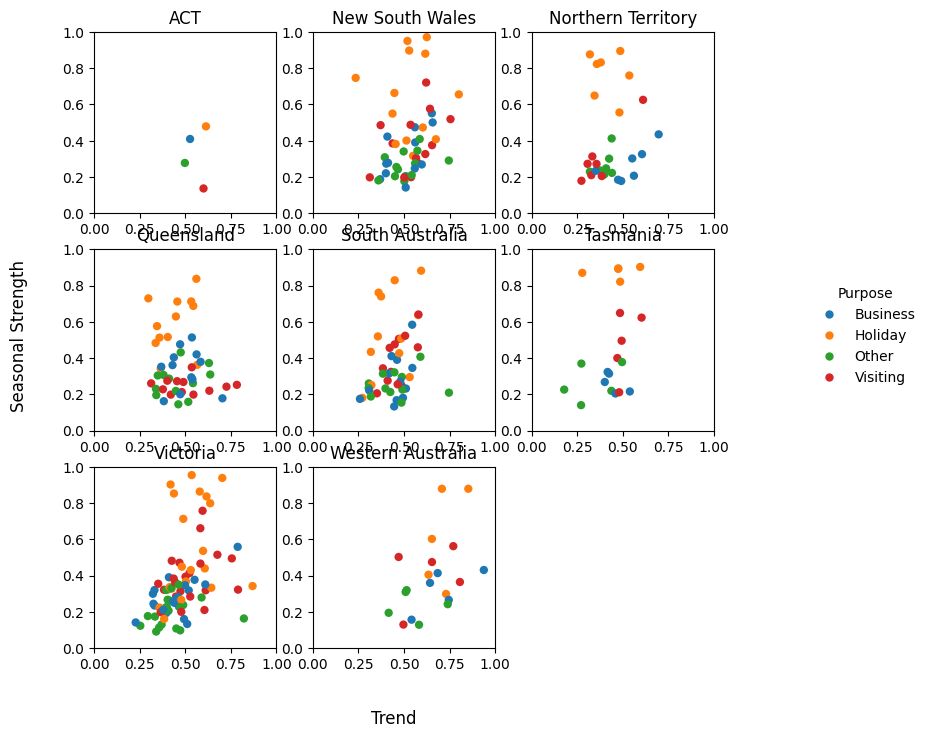

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns


df = (
    stl_feat["unique_id"].str.split("-", expand=True)
    .rename(columns={0: "region", 1: "state", 2: "purpose"})
    .join(stl_feat)
)
fig, axs = plt.subplots(3, 3, figsize=(8, 8))
axs = axs.flatten()
for ax, (state, state_df) in zip(axs, df.groupby('state')):
    sns.scatterplot(x="trend", y="seasonal_strength",
        hue="purpose", edgecolor="none", data=state_df, ax=ax)
    ax.get_legend().remove()
    ax.set(title=state, xlabel="", ylabel="", xlim=(0, 1), ylim=(0, 1))
handles, labels = ax.get_legend_handles_labels()
fig.legend(handles, labels,
    title="Purpose", loc="center left", frameon=False,
    bbox_to_anchor=(1.02, .5), borderaxespad=0)
fig.supxlabel('Trend')
fig.supylabel('Seasonal Strength')

# Remove any empty subplots
for ax in axs:
    if not ax.lines:
        ax.set_visible(False)

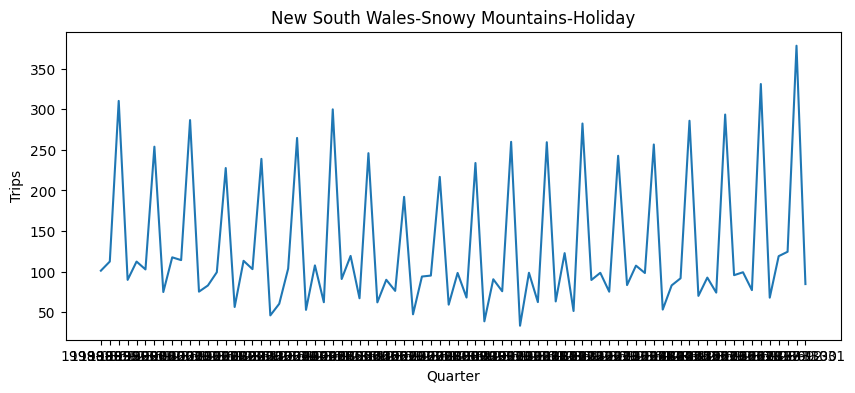

In [17]:
from utilsforecast.plotting import plot_series

import matplotlib.pyplot as plt

series = aus_tourism.loc[
    aus_tourism["unique_id"] == row["unique_id"]
]

plt.figure(figsize=(10, 4))
plt.plot(series["ds"], series["y"])
plt.title("New South Wales-Snowy Mountains-Holiday")
plt.xlabel("Quarter")
plt.ylabel("Trips")
plt.show()

# 4.5 exploring australian tourism data

In [ ]:
all_features = [
    tsf.acf_features,
    tsf.arch_stat,
    tsf.crossing_points,
    tsf.entropy,
    tsf.flat_spots,
    tsf.heterogeneity,
    tsf.holt_parameters,
    tsf.lumpiness,
    tsf.nonlinearity,
    tsf.pacf_features,
    tsf.stl_features,
    tsf.stability,
    tsf.hw_parameters,
    tsf.unitroot_kpss,
    tsf.unitroot_pp,
    tsf.series_length,
    tsf.hurst,
]
all_feat = tsf.tsfeatures(aus_tourism, freq=4, features=all_features)
all_feat.head(10)

# This gives 42 features for every combination of the three key variables (Region, State and Purpose). 
# We can treat this dataframe like any data set and analyse it to find interesting observations or groups of observations.

,unique_id,hurst,series_length,unitroot_pp,unitroot_kpss,hw_alpha,hw_beta,hw_gamma,stability,nperiods,...,entropy,crossing_points,arch_lm,x_acf1,x_acf10,diff1_acf1,diff1_acf10,diff2_acf1,diff2_acf10,seas_acf1
0,Adelaide Hills-South Australia-Business,NaN,80,-80.527131,0.059545,1.490116e-08,1.219903e-08,0.000000,0.293653,1,...,0.894660,36,0.014362,0.070915,0.134473,-0.579504,0.414537,-0.750404,0.746004,-0.062808
1,Adelaide Hills-South Australia-Holiday,0.822970,80,-74.302188,0.476403,9.899014e-02,9.899014e-02,0.000000,0.408978,1,...,0.830890,33,0.120527,0.131320,0.312710,-0.536153,0.500211,-0.716343,0.906314,0.208042
2,Adelaide Hills-South Australia-Other,0.599001,80,-55.384688,0.604552,1.490116e-08,1.480781e-08,0.179854,0.273886,1,...,0.862339,37,0.265443,0.261143,0.330169,-0.253227,0.317087,-0.457470,0.392235,0.074534
3,Adelaide Hills-South Australia-Visiting,0.756890,80,-71.076026,0.749431,1.490116e-08,1.150052e-09,0.000000,0.333059,1,...,0.907152,25,0.004941,0.139167,0.116787,-0.472006,0.238615,-0.625575,0.407713,0.169772
4,Adelaide-South Australia-Business,0.839906,80,-78.764248,0.220978,1.305853e-01,1.305853e-01,0.000000,0.317769,1,...,0.848084,43,0.182907,0.033271,0.130646,-0.519622,0.462537,-0.676429,0.741357,0.200875
5,Adelaide-South Australia-Holiday,0.708848,80,-72.567094,0.448565,1.758048e-01,1.758048e-01,0.000000,0.312279,1,...,0.736811,36,0.161045,0.045570,0.371898,-0.342625,0.614365,-0.486833,0.558244,0.351151
6,Adelaide-South Australia-Other,0.776053,80,-36.405038,1.406211,1.068326e-01,7.714909e-02,0.000000,0.573715,1,...,0.755293,28,0.455923,0.516806,1.153598,-0.408620,0.382891,-0.675120,0.792353,0.341781
7,Adelaide-South Australia-Visiting,0.737366,80,-74.136566,0.263653,1.629560e-01,0.000000e+00,0.000000,0.267454,1,...,0.775936,42,0.173340,0.068365,0.294237,-0.393654,0.452291,-0.517959,0.447296,0.344930
8,Alice Springs-Northern Territory-Business,0.672664,80,-65.844696,0.806786,1.456158e-01,0.000000e+00,0.000000,0.439484,1,...,0.850637,33,0.424878,0.217424,0.366634,-0.499585,0.380557,-0.657996,0.587038,0.315314
9,Alice Springs-Northern Territory-Holiday,0.578587,80,-54.381905,0.387297,1.490116e-08,7.911713e-09,0.000000,0.083596,1,...,0.412425,40,0.304123,-0.006605,2.113374,-0.152790,2.113436,-0.274286,1.550737,0.728589


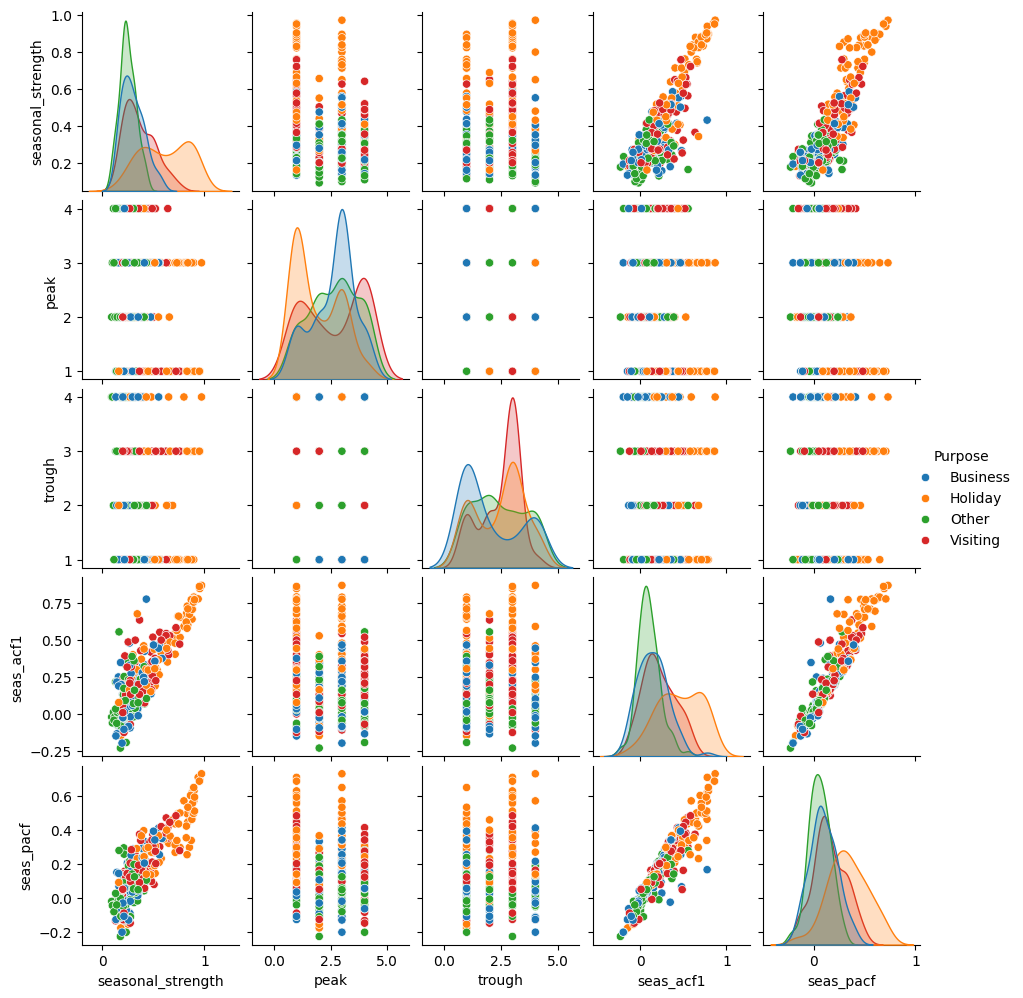

In [20]:
seasonal_feat = all_feat[
    ["unique_id", "seasonal_strength", "peak", "trough",
     "seas_acf1", "seas_pacf"]
]
df = (
    seasonal_feat["unique_id"].str.split("-", expand=True)
    .rename(columns={0: "region", 1: "state", 2: "Purpose"})
    .join(seasonal_feat)
)
g = sns.pairplot(df, hue="Purpose")
g.fig.set_size_inches(10, 10)
plt.show()

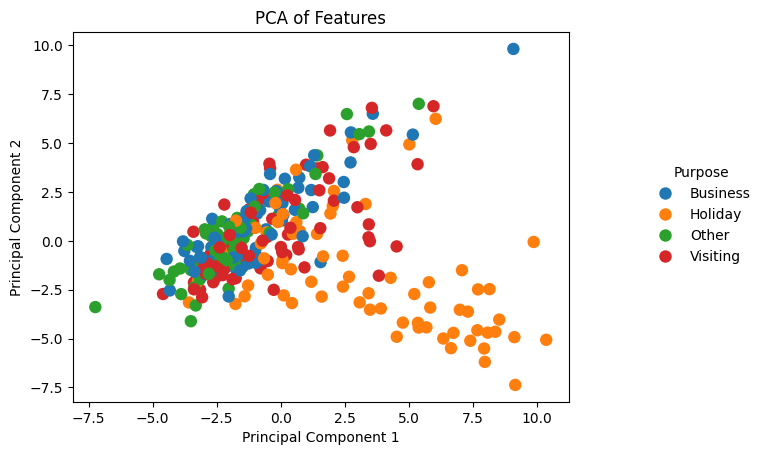

In [24]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA


df = (
    all_feat
    .assign(purpose=lambda x: x["unique_id"].str.split("-").str[-1])
    .dropna(axis='columns')
)
X = df.drop(columns=["unique_id", "purpose"])
pipeline = Pipeline([
    ('scale', StandardScaler()),
    ('pca', PCA(n_components=2)),
])
principal_components = pipeline.fit_transform(X)
pca_df = (
    pd.DataFrame(data=principal_components, columns=["PC1", "PC2"])
    .join(df[["unique_id", "purpose"]])
)
fig, ax = plt.subplots()
sns.scatterplot(x="PC1", y="PC2", s=80,
    hue="purpose", edgecolor="none", data=pca_df, ax=ax)
ax.set(
    title="PCA of Features",
    xlabel="Principal Component 1",
    ylabel="Principal Component 2",
)
ax.get_legend().remove()
handles, labels = ax.get_legend_handles_labels()
fig.legend(handles, labels,
    title="Purpose", loc="center left", frameon=False,
    bbox_to_anchor=(1.02, .5), borderaxespad=0)
plt.show()